In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df_credit = pd.read_csv("creditcard.csv")

In [3]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

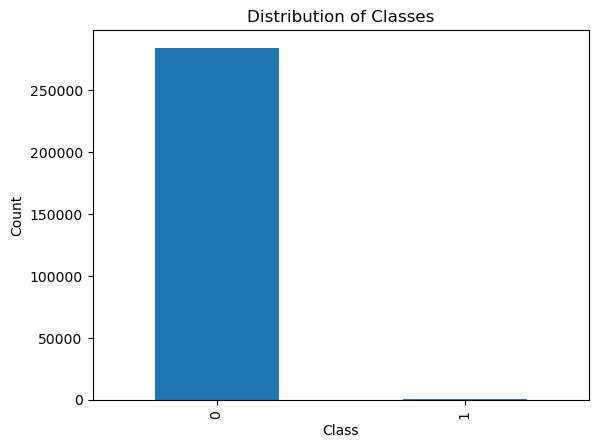

In [4]:
df_credit['Class'].value_counts().plot(kind='bar')
plt.title('Distribution of Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='Class', ylabel='count'>

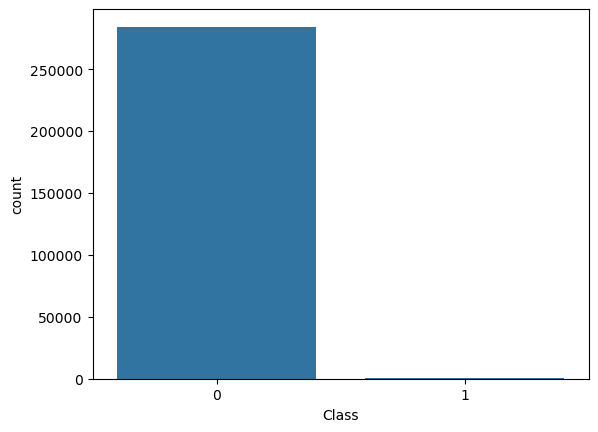

In [5]:
import seaborn as sns
sns.countplot(x='Class', data=df_credit)

Text(0.5, 1.0, 'Distribution of Transaction Amounts')

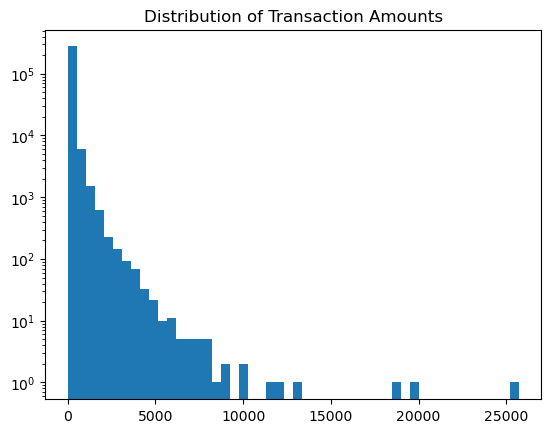

In [6]:
plt.hist(df_credit['Amount'], bins=50)
plt.yscale('log')
plt.title('Distribution of Transaction Amounts')

<Axes: xlabel='Class', ylabel='Amount'>

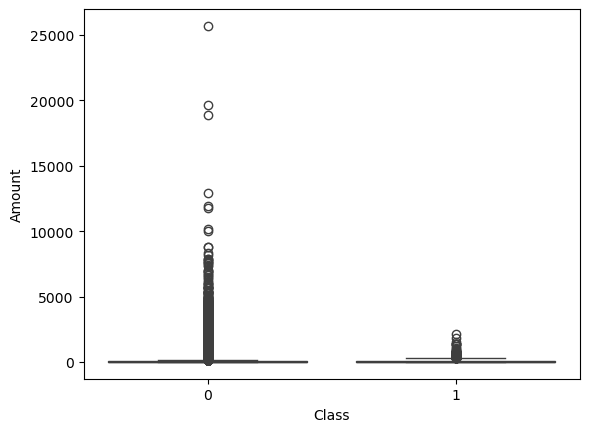

In [7]:
sns.boxplot(x='Class', y='Amount', data=df_credit)

<Axes: xlabel='Hour', ylabel='count'>

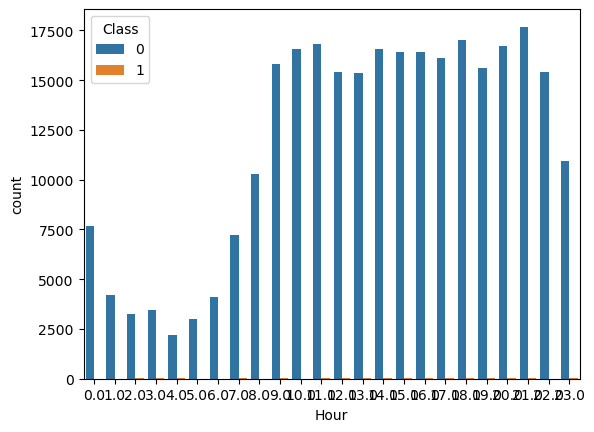

In [8]:
df_credit['Hour'] = df_credit['Time'] // 3600 % 24
sns.countplot(x='Hour', hue='Class', data=df_credit)

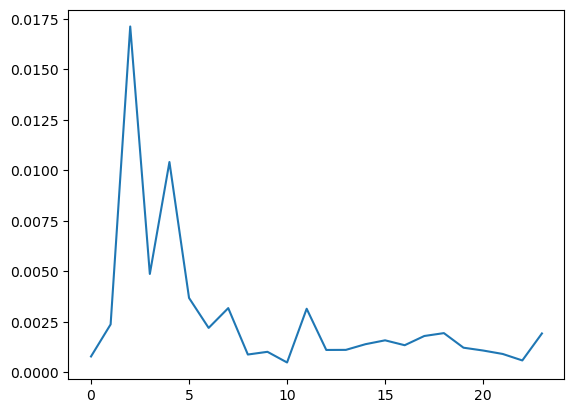

In [9]:
fraud_by_hour = df_credit.groupby('Hour')['Class'].mean()
plt.plot(fraud_by_hour.index, fraud_by_hour.values)

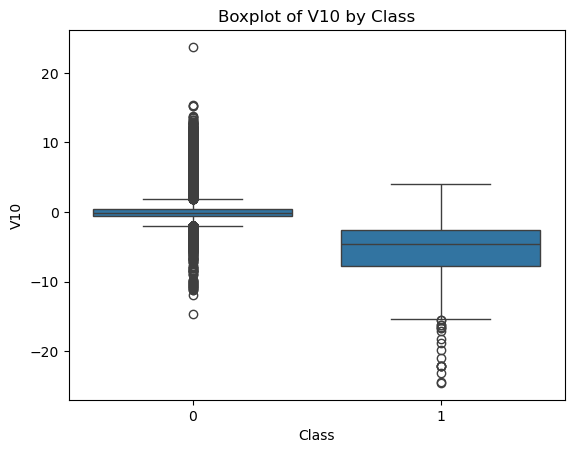

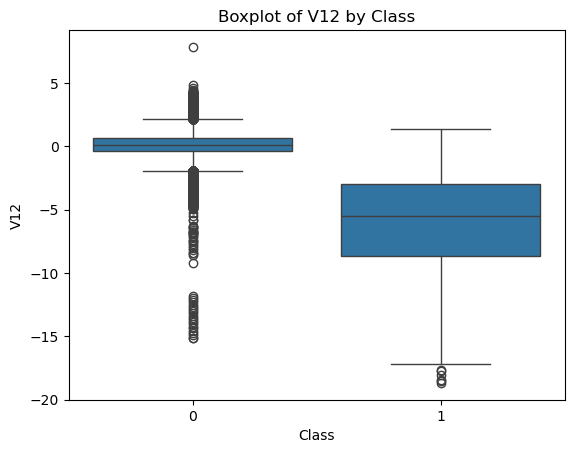

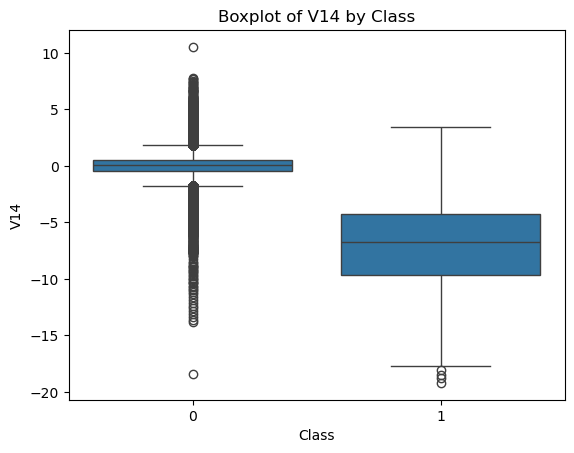

In [10]:
for col in ['V10', 'V12', 'V14']:
    sns.boxplot(x='Class', y=col, data=df_credit)
    plt.title(f'Boxplot of {col} by Class')
    plt.show()    

<Axes: >

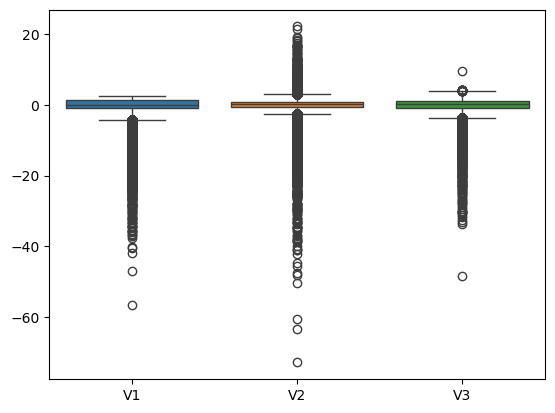

In [11]:
sns.boxplot(data=df_credit[['V1', 'V2', 'V3']])

Text(0.5, 1.0, 'PCA of Credit Card Transactions')

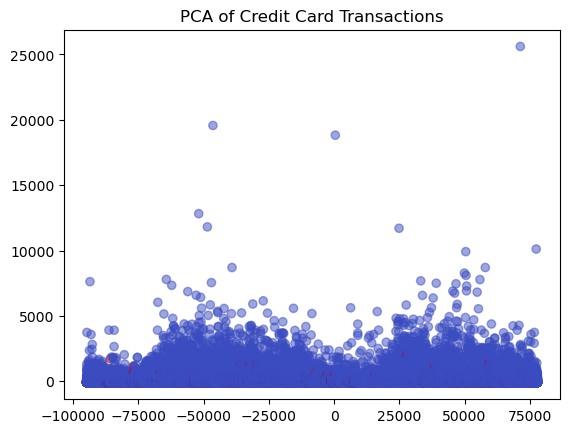

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_credit.drop("Class", axis=1))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_credit['Class'], cmap='coolwarm', alpha=0.5)
plt.title('PCA of Credit Card Transactions')


In [13]:
df_credit['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


def compare_fraud_models(df, target_col='Class', test_size=0.2, random_state=42):
    """
    Train and compare 3 fraud detection models on the same dataset.

    Parameters:
        df (pd.DataFrame): Input dataset
        target_col (str): Target column name
        test_size (float): Test split size
        random_state (int): Random seed

    Returns:
        results_df (pd.DataFrame): Comparison table
        best_model_name (str): Name of best model based on PR-AUC
        best_model (object): Trained best model
    """

    # Split features and target
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # Train-test split with stratify because fraud data is imbalanced
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    # Define models
    models = {
        'Logistic Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=random_state))
        ]),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=random_state,
            n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            random_state=random_state
        )
    }

    results = []
    trained_models = {}

    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)

        # Predict labels
        y_pred = model.predict(X_test)

        # Predict probabilities
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = None

        # Metrics
        metrics = {
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, zero_division=0),
            'Recall': recall_score(y_test, y_pred, zero_division=0),
            'F1 Score': f1_score(y_test, y_pred, zero_division=0),
            'ROC-AUC': roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
            'PR-AUC': average_precision_score(y_test, y_prob) if y_prob is not None else np.nan,
            'Confusion Matrix': confusion_matrix(y_test, y_pred).tolist()
        }

        results.append(metrics)
        trained_models[name] = model

    results_df = pd.DataFrame(results).sort_values(by='PR-AUC', ascending=False).reset_index(drop=True)

    best_model_name = results_df.iloc[0]['Model']
    best_model = trained_models[best_model_name]

    return results_df, best_model_name, best_model

In [15]:
results_df, best_model_name, best_model = compare_fraud_models(df_credit)

print(results_df)
print("Best Model:", best_model_name)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC  \
0        Random Forest  0.999526   0.961039  0.755102  0.845714  0.957983   
1  Logistic Regression  0.973491   0.055975  0.908163  0.105450  0.973778   
2    Gradient Boosting  0.998315   0.529412  0.183673  0.272727  0.346886   

     PR-AUC          Confusion Matrix  
0  0.864339    [[56861, 3], [24, 74]]  
1  0.723683  [[55363, 1501], [9, 89]]  
2  0.156654   [[56848, 16], [80, 18]]  
Best Model: Random Forest


In [16]:
import joblib
joblib.dump(best_model, 'best_fraud_model.joblib')

['best_fraud_model.joblib']

In [17]:
df_1 = pd.read_csv("drift_1.csv")
df_2 = pd.read_csv("drift_2.csv")
df_3 = pd.read_csv("drift_3.csv")
df_4 = pd.read_csv("drift_4.csv")
df_5 = pd.read_csv("drift_5.csv")

In [18]:
df_1.groupby("day")["Class"].mean()

day
0     0.004
1     0.000
2     0.004
3     0.000
4     0.006
5     0.006
6     0.002
7     0.002
8     0.002
9     0.002
10    0.002
11    0.000
12    0.002
13    0.000
14    0.002
15    0.000
16    0.004
17    0.004
18    0.000
19    0.002
20    0.002
21    0.002
22    0.004
23    0.000
24    0.000
25    0.002
26    0.002
27    0.000
28    0.002
29    0.000
Name: Class, dtype: float64

In [19]:
model = joblib.load("best_fraud_model.joblib")

In [20]:
import pandas as pd
import joblib
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score

feature_cols = [col for col in df_credit.drop(columns=["Class"]).columns]

files = ["drift_1.csv", "drift_2.csv", "drift_3.csv", "drift_4.csv", "drift_5.csv"]
results = []

for file in files:
    df_new = pd.read_csv(file)

    # Apply same preprocessing as training
    df_new["Hour"] = (df_new["Time"] // 3600) % 24
    df_new = df_new.drop(columns=["day"])

    X = df_new.drop(columns=["Class"])
    y = df_new["Class"]

    # Ensure exact same columns and order
    X = X[feature_cols]

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    results.append({
        "Dataset": file,
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0),
        "PR-AUC": average_precision_score(y, y_prob)
    })

metrics_df = pd.DataFrame(results)
print(metrics_df)

       Dataset  Precision    Recall        F1    PR-AUC
0  drift_1.csv        0.0  0.000000  0.000000  0.002239
1  drift_2.csv        0.0  0.000000  0.000000  0.003443
2  drift_3.csv        1.0  0.202128  0.336283  0.988205
3  drift_4.csv        0.0  0.000000  0.000000  0.001939
4  drift_5.csv        1.0  0.093333  0.170732  0.739169


The model initially performed well but degraded significantly when exposed to new data distributions, highlighting the need for continuous monitoring and retraining. 

In [21]:
print(y_prob[:10])
print(y_prob.mean())
print(y_prob.max())

[0.01 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
0.005546666666666667
0.84


Data drift check

In [22]:
from scipy.stats import ks_2samp

def detect_feature_drift(train_df, prod_df, features, alpha=0.05):
    drift_results = []

    for col in features:
        stat, p_value = ks_2samp(train_df[col], prod_df[col])
        drift_results.append({
            "Feature": col,
            "KS Statistic": stat,
            "p-value": p_value,
            "Drift Detected": p_value < alpha
        })

    return pd.DataFrame(drift_results)

In [23]:
def generate_alerts(metrics_row, baseline_row):
    alerts = []

    if metrics_row["Recall"] < baseline_row["Recall"] * 0.8:
        alerts.append("Critical recall degradation")

    if metrics_row["F1"] < baseline_row["F1"] * 0.8:
        alerts.append("Critical F1 degradation")

    return alerts


Loading baseline dataset...

Training and comparing baseline models...

=== MODEL COMPARISON ===
                 Model  Accuracy  Precision    Recall        F1   ROC-AUC  \
0        Random Forest  0.999526   0.961039  0.755102  0.845714  0.962229   
1    Gradient Boosting  0.998315   0.529412  0.183673  0.272727  0.346886   
2  Logistic Regression  0.973491   0.055975  0.908163  0.105450  0.973778   

     PR-AUC          Confusion Matrix  
0  0.866874    [[56861, 3], [24, 74]]  
1  0.156654   [[56848, 16], [80, 18]]  
2  0.723683  [[55363, 1501], [9, 89]]  

Best Model: Random Forest
Saved baseline model to: fraud_model_baseline.pkl

=== BASELINE METRICS ===
Dataset: Baseline Test
Accuracy: 0.9995259997893332
Precision: 0.961038961038961
Recall: 0.7551020408163265
F1: 0.8457142857142858
ROC-AUC: 0.9622294296165287
PR-AUC: 0.8668740190725254
Confusion Matrix: [[56861, 3], [24, 74]]
Predicted Fraud Count: 77

Processing drift_1.csv...

Performance:
       Dataset  Precision  Recall   

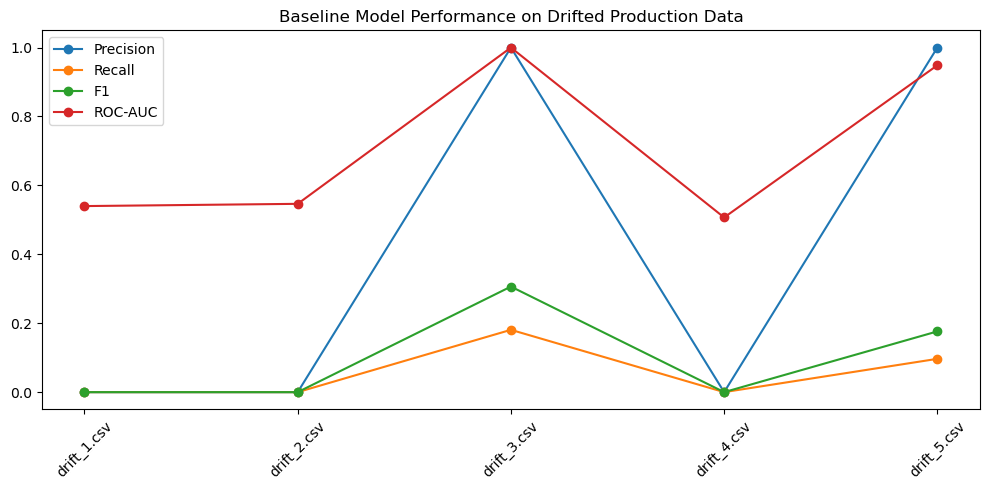


Plotting train vs production distributions for selected features...


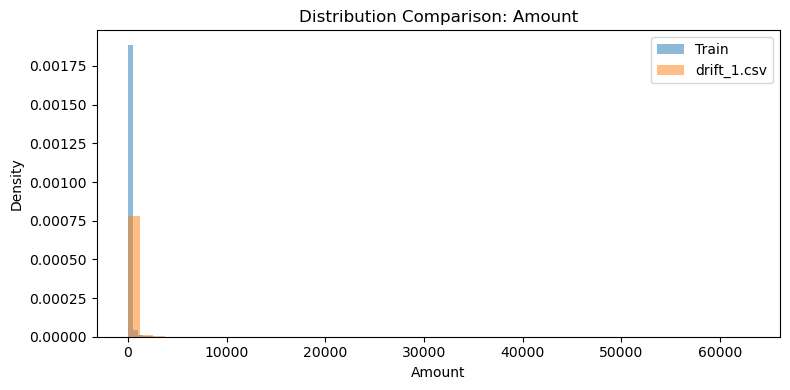

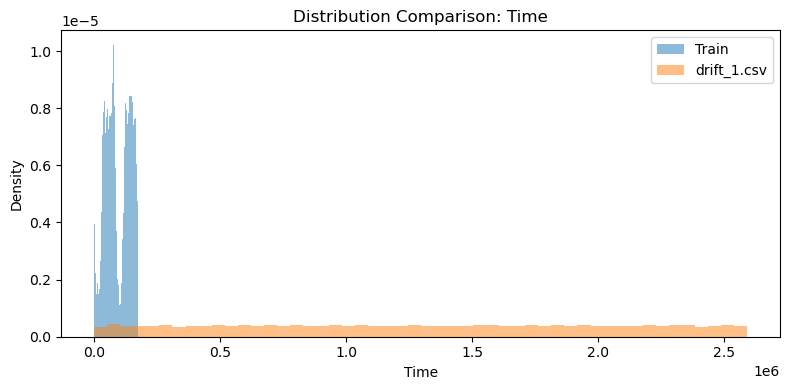

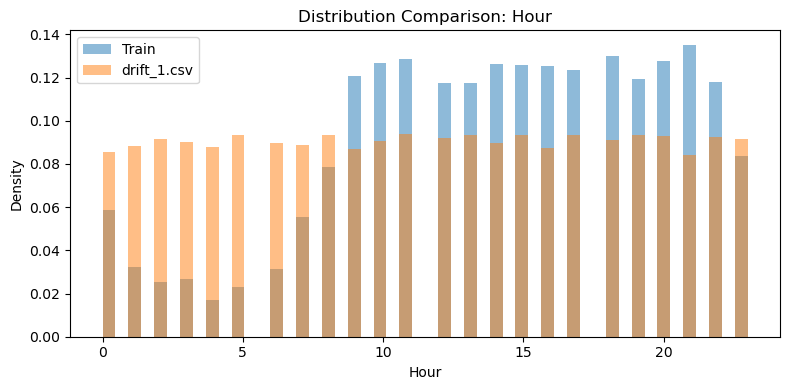

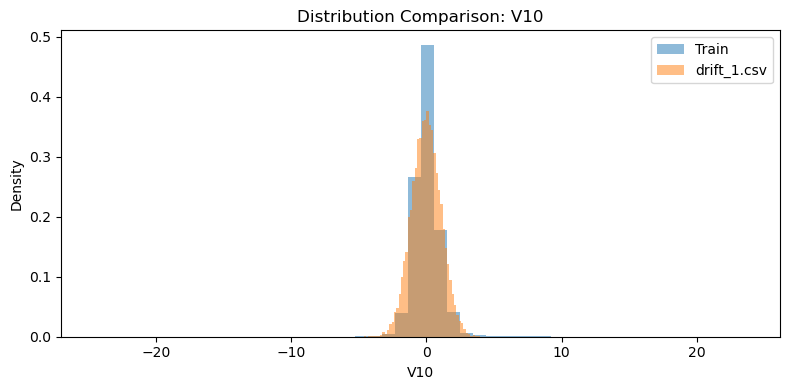

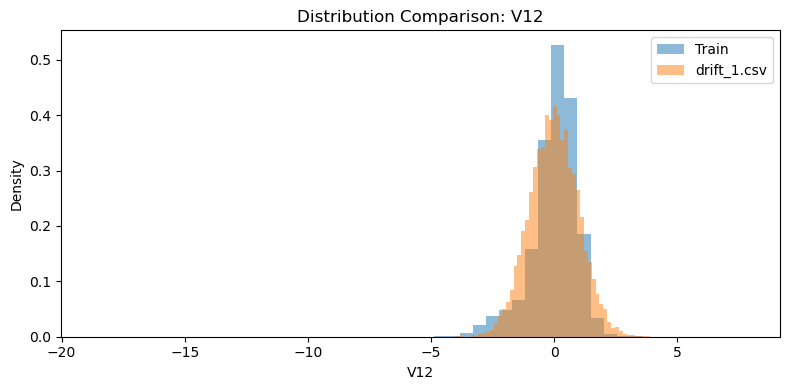

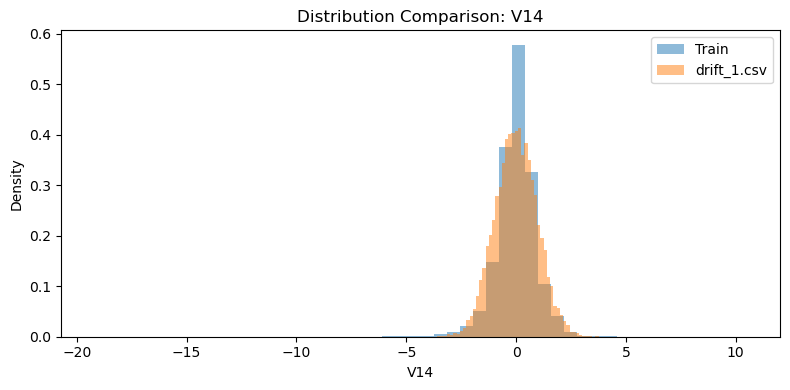


Retraining recommended based on: drift_5.csv

=== RETRAINED MODEL PERFORMANCE ===
                    Dataset  Precision  Recall   F1  ROC-AUC  PR-AUC
0  Retrained on drift_5.csv        1.0     1.0  1.0      1.0     1.0

=== FINAL PERFORMANCE TABLE ===
       Dataset  Precision    Recall        F1   ROC-AUC    PR-AUC  \
0  drift_1.csv        0.0  0.000000  0.000000  0.539957  0.002171   
1  drift_2.csv        0.0  0.000000  0.000000  0.546476  0.004744   
2  drift_3.csv        1.0  0.180851  0.306306  0.999977  0.995370   
3  drift_4.csv        0.0  0.000000  0.000000  0.506899  0.001778   
4  drift_5.csv        1.0  0.096667  0.176292  0.948575  0.790365   

                                              Alerts Retrain Recommended  
0  Critical: Recall dropped by more than 20% | Cr...                 Yes  
1  Critical: Recall dropped by more than 20% | Cr...                 Yes  
2  Critical: Recall dropped by more than 20% | Cr...                 Yes  
3  Critical: Recall dropped by 

In [24]:
# =========================
# 1. IMPORTS
# =========================
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# =========================
# 2. CONFIG
# =========================
BASE_DATA_FILE = "creditcard.csv"
DRIFT_FILES = ["drift_1.csv", "drift_2.csv", "drift_3.csv", "drift_4.csv", "drift_5.csv"]

MODEL_SAVE_PATH = "fraud_model_baseline.pkl"
FEATURES_SAVE_PATH = "baseline_feature_columns.pkl"

RANDOM_STATE = 42
TEST_SIZE = 0.2


# =========================
# 3. PREPROCESSING
# =========================
def prepare_features(df: pd.DataFrame, training: bool = False) -> pd.DataFrame:
    """
    Apply the same preprocessing to baseline and drift datasets.
    """
    df = df.copy()

    # Create Hour feature if not already present
    if "Hour" not in df.columns and "Time" in df.columns:
        df["Hour"] = (df["Time"] // 3600) % 24

    # Drop day if present in drift data
    if "day" in df.columns:
        df = df.drop(columns=["day"])

    return df


# =========================
# 4. MODEL COMPARISON
# =========================
def compare_fraud_models(df: pd.DataFrame, target_col: str = "Class", sort_metric: str = "F1"):
    """
    Compare 3 models and return results + best model.
    """
    df = prepare_features(df)

    X = df.drop(columns=[target_col])
    y = df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    models = {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=RANDOM_STATE
            ))
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    }

    results = []
    trained_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        y_prob = None
        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]

        row = {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan,
            "PR-AUC": average_precision_score(y_test, y_prob) if y_prob is not None else np.nan,
            "Confusion Matrix": confusion_matrix(y_test, y_pred).tolist()
        }

        results.append(row)
        trained_models[name] = model

    results_df = pd.DataFrame(results).sort_values(by=sort_metric, ascending=False).reset_index(drop=True)

    best_model_name = results_df.iloc[0]["Model"]
    best_model = trained_models[best_model_name]

    return results_df, best_model_name, best_model, X_train.columns.tolist(), X_train, X_test, y_train, y_test


# =========================
# 5. BASELINE EVALUATION
# =========================
def evaluate_model(model, X, y, dataset_name="dataset", threshold=0.5):
    """
    Evaluate a trained model on a dataset.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    results = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1": f1_score(y, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, y_prob),
        "PR-AUC": average_precision_score(y, y_prob),
        "Confusion Matrix": confusion_matrix(y, y_pred).tolist(),
        "Predicted Fraud Count": int(y_pred.sum())
    }
    return results


# =========================
# 6. PSI CALCULATION
# =========================
def calculate_psi(expected, actual, buckets=10):
    """
    Population Stability Index.
    """
    expected = np.asarray(expected)
    actual = np.asarray(actual)

    breakpoints = np.percentile(expected, np.arange(0, 100 + 100 / buckets, 100 / buckets))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]

    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    # avoid divide-by-zero
    expected_perc = np.where(expected_perc == 0, 1e-6, expected_perc)
    actual_perc = np.where(actual_perc == 0, 1e-6, actual_perc)

    psi = np.sum((actual_perc - expected_perc) * np.log(actual_perc / expected_perc))
    return psi


# =========================
# 7. DRIFT DETECTION
# =========================
def detect_feature_drift(train_df, prod_df, feature_cols, alpha=0.05):
    """
    Detect drift using KS test + PSI.
    """
    results = []

    for col in feature_cols:
        train_vals = train_df[col].dropna()
        prod_vals = prod_df[col].dropna()

        ks_stat, p_value = ks_2samp(train_vals, prod_vals)
        psi_value = calculate_psi(train_vals, prod_vals, buckets=10)

        if psi_value < 0.1:
            psi_label = "No/Low Drift"
        elif psi_value < 0.25:
            psi_label = "Moderate Drift"
        else:
            psi_label = "Major Drift"

        drift_flag = (p_value < alpha) or (psi_value >= 0.1)

        results.append({
            "Feature": col,
            "KS Statistic": ks_stat,
            "p-value": p_value,
            "PSI": psi_value,
            "PSI Level": psi_label,
            "Drift Detected": drift_flag
        })

    drift_df = pd.DataFrame(results).sort_values(by=["Drift Detected", "PSI"], ascending=[False, False])
    return drift_df


# =========================
# 8. VISUALIZE TRAIN VS PRODUCTION
# =========================
def plot_feature_distributions(train_df, prod_df, features, prod_name):
    """
    Plot train vs production feature distributions.
    """
    for col in features:
        plt.figure(figsize=(8, 4))
        plt.hist(train_df[col], bins=50, alpha=0.5, label="Train", density=True)
        plt.hist(prod_df[col], bins=50, alpha=0.5, label=prod_name, density=True)
        plt.title(f"Distribution Comparison: {col}")
        plt.xlabel(col)
        plt.ylabel("Density")
        plt.legend()
        plt.tight_layout()
        plt.show()


# =========================
# 9. ALERT / MONITORING RULES
# =========================
def generate_performance_alerts(current_metrics, baseline_metrics):
    """
    Rule-based monitoring alerts.
    """
    alerts = []

    if current_metrics["Recall"] < baseline_metrics["Recall"] * 0.8:
        alerts.append("Critical: Recall dropped by more than 20%")

    if current_metrics["F1"] < baseline_metrics["F1"] * 0.8:
        alerts.append("Critical: F1 dropped by more than 20%")

    if current_metrics["ROC-AUC"] < baseline_metrics["ROC-AUC"] * 0.9:
        alerts.append("Warning: ROC-AUC dropped by more than 10%")

    if current_metrics["PR-AUC"] < baseline_metrics["PR-AUC"] * 0.9:
        alerts.append("Warning: PR-AUC dropped by more than 10%")

    return alerts


def generate_drift_alerts(drift_df):
    """
    Drift-based alerts from feature drift table.
    """
    major_drift_count = (drift_df["PSI Level"] == "Major Drift").sum()
    moderate_drift_count = (drift_df["PSI Level"] == "Moderate Drift").sum()

    alerts = []

    if major_drift_count >= 3:
        alerts.append(f"Critical: {major_drift_count} features show major drift")

    if moderate_drift_count >= 5:
        alerts.append(f"Warning: {moderate_drift_count} features show moderate drift")

    return alerts


# =========================
# 10. RETRAINING STRATEGY
# =========================
def retrain_model_on_new_data(original_df, new_df, target_col="Class"):
    """
    Example retraining strategy:
    combine original + new data and retrain Random Forest.
    """
    original_df = prepare_features(original_df)
    new_df = prepare_features(new_df)

    combined_df = pd.concat([original_df, new_df], ignore_index=True)

    X = combined_df.drop(columns=[target_col])
    y = combined_df[target_col]

    model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X, y)

    return model, X.columns.tolist()


# =========================
# 11. MAIN PIPELINE
# =========================
def main():
    # -------------------------
    # Load baseline data
    # -------------------------
    print("\nLoading baseline dataset...")
    baseline_df = pd.read_csv(BASE_DATA_FILE)
    baseline_df = prepare_features(baseline_df)

    # -------------------------
    # Compare candidate models
    # -------------------------
    print("\nTraining and comparing baseline models...")
    results_df, best_model_name, best_model, feature_cols, X_train, X_test, y_train, y_test = compare_fraud_models(
        baseline_df,
        target_col="Class",
        sort_metric="F1"
    )

    print("\n=== MODEL COMPARISON ===")
    print(results_df)

    # -------------------------
    # Save baseline model + columns
    # -------------------------
    joblib.dump(best_model, MODEL_SAVE_PATH)
    joblib.dump(feature_cols, FEATURES_SAVE_PATH)

    print(f"\nBest Model: {best_model_name}")
    print(f"Saved baseline model to: {MODEL_SAVE_PATH}")

    # -------------------------
    # Baseline metrics
    # -------------------------
    baseline_metrics = evaluate_model(best_model, X_test, y_test, dataset_name="Baseline Test")
    print("\n=== BASELINE METRICS ===")
    for k, v in baseline_metrics.items():
        print(f"{k}: {v}")

    # -------------------------
    # Store production monitoring results
    # -------------------------
    performance_results = []
    all_drift_tables = {}

    train_reference_df = baseline_df[feature_cols + ["Class"]].copy()

    # -------------------------
    # Evaluate on drift datasets
    # -------------------------
    for file in DRIFT_FILES:
        print(f"\nProcessing {file}...")

        prod_df = pd.read_csv(file)
        prod_df = prepare_features(prod_df)

        # Keep only needed columns
        X_prod = prod_df.drop(columns=["Class"])
        y_prod = prod_df["Class"]

        # Ensure exact feature order
        X_prod = X_prod[feature_cols]
        prod_reference_df = prod_df[feature_cols + ["Class"]].copy()

        # Performance evaluation
        current_metrics = evaluate_model(best_model, X_prod, y_prod, dataset_name=file)
        perf_alerts = generate_performance_alerts(current_metrics, baseline_metrics)

        # Drift detection
        drift_df = detect_feature_drift(
            train_df=train_reference_df[feature_cols],
            prod_df=prod_reference_df[feature_cols],
            feature_cols=feature_cols,
            alpha=0.05
        )
        drift_alerts = generate_drift_alerts(drift_df)

        all_alerts = perf_alerts + drift_alerts

        current_metrics["Alerts"] = " | ".join(all_alerts) if all_alerts else "No alerts"
        current_metrics["Retrain Recommended"] = "Yes" if len(all_alerts) > 0 else "No"

        performance_results.append(current_metrics)
        all_drift_tables[file] = drift_df

        print("\nPerformance:")
        print(pd.DataFrame([current_metrics])[["Dataset", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "Alerts", "Retrain Recommended"]])

        print("\nTop drifted features:")
        print(drift_df.head(10))

    performance_df = pd.DataFrame(performance_results)

    # -------------------------
    # Plot performance drift over time
    # -------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(performance_df["Dataset"], performance_df["Precision"], marker="o", label="Precision")
    plt.plot(performance_df["Dataset"], performance_df["Recall"], marker="o", label="Recall")
    plt.plot(performance_df["Dataset"], performance_df["F1"], marker="o", label="F1")
    plt.plot(performance_df["Dataset"], performance_df["ROC-AUC"], marker="o", label="ROC-AUC")
    plt.xticks(rotation=45)
    plt.title("Baseline Model Performance on Drifted Production Data")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -------------------------
    # Example distribution plots
    # -------------------------
    # You can change these features based on importance or drift
    sample_prod = pd.read_csv(DRIFT_FILES[0])
    sample_prod = prepare_features(sample_prod)

    print("\nPlotting train vs production distributions for selected features...")
    plot_feature_distributions(
        train_df=baseline_df,
        prod_df=sample_prod,
        features=["Amount", "Time", "Hour", "V10", "V12", "V14"],
        prod_name=DRIFT_FILES[0]
    )

    # -------------------------
    # Example retraining trigger
    # -------------------------
    retrain_candidates = performance_df[performance_df["Retrain Recommended"] == "Yes"]

    if not retrain_candidates.empty:
        latest_bad_file = retrain_candidates.iloc[-1]["Dataset"]
        print(f"\nRetraining recommended based on: {latest_bad_file}")

        latest_bad_df = pd.read_csv(latest_bad_file)
        retrained_model, retrained_features = retrain_model_on_new_data(baseline_df, latest_bad_df)

        latest_bad_df = prepare_features(latest_bad_df)
        X_latest = latest_bad_df.drop(columns=["Class"])[retrained_features]
        y_latest = latest_bad_df["Class"]

        retrained_metrics = evaluate_model(retrained_model, X_latest, y_latest, dataset_name=f"Retrained on {latest_bad_file}")

        print("\n=== RETRAINED MODEL PERFORMANCE ===")
        print(pd.DataFrame([retrained_metrics])[["Dataset", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]])
    else:
        print("\nNo retraining needed based on current monitoring rules.")

    # -------------------------
    # Final outputs
    # -------------------------
    print("\n=== FINAL PERFORMANCE TABLE ===")
    print(performance_df[["Dataset", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "Alerts", "Retrain Recommended"]])

    return {
        "model_comparison": results_df,
        "baseline_metrics": baseline_metrics,
        "production_performance": performance_df,
        "drift_tables": all_drift_tables
    }


# =========================
# 12. RUN
# =========================
if __name__ == "__main__":
    outputs = main()